## Imports

In [15]:
%load_ext autoreload
%autoreload 2

import logging

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set plotting style.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import growth_function as mtugrowf
import msml610_utils as ut

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

INFO:msml610_utils:Setting notebook style
INFO:msml610_utils:Notebook signature
INFO:msml610_utils:numpy version=1.26.4
INFO:msml610_utils:pymc version=5.18.2
INFO:msml610_utils:matplotlib version=3.10.3
INFO:msml610_utils:arviz version=0.21.0
INFO:msml610_utils:preliz version=0.19.0


Python 3.12.3
Linux 589569fe8102 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 aarch64 aarch64 GNU/Linux


## Background: The Growth Function

### What is the Growth Function?

The **growth function** $m_H(N)$ measures the expressive power of a hypothesis set $H$:

$$m_H(N) = \max_{x_1, \ldots, x_N} |\{(h(x_1), \ldots, h(x_N)) : h \in H\}|$$

In other words, it counts the maximum number of different ways (dichotomies) that $H$ can classify $N$ points.

### Key Concepts

- **Dichotomy**: A binary labeling of $N$ points (there are $2^N$ possible dichotomies)
- **Shattered Points**: Points where all $2^N$ dichotomies are realizable ($m_H(N) = 2^N$)
- **Break Point**: The first $N$ where $m_H(N) < 2^N$
- **VC Dimension**: The largest $N$ for which some configuration of $N$ points can be shattered

### Why It Matters

- If $m_H(N)$ grows polynomially, learning is feasible
- If $m_H(N)$ grows exponentially, overfitting is likely
- The VC dimension controls generalization bounds

## Cell 1: Positive Rays

**Hypothesis Set**: $h(x) = \text{sign}(x - a)$ for some threshold $a$

**Theoretical Growth Function**: $m_H(N) = N + 1$

**VC Dimension**: 1

Let's compute the growth function empirically and verify it matches theory.

In [17]:
# Create point generator and hypothesis tester for positive rays.
generator = mtugrowf.PointGenerator(seed=42)
tester = mtugrowf.PositiveRaysTester()
calculator = mtugrowf.GrowthFunctionCalculator(
    tester, verbose=True, show_progress=False
)

# Generate 5 points on a 1D line.
n = 5
points = generator.generate_line_1d(n=n)
print(f"\nGenerated {n} points on 1D line:")
print(f"Points: {points.flatten()}")

# Compute growth function.
result = calculator.compute_growth_function(points)

print(f"\n=== Results for Positive Rays (N={n}) ===")
print(f"m_H({n}) = {result['m_h_n']}")
print(f"Theoretical (N+1) = {n + 1}")
print(f"Maximum possible (2^N) = {result['max_dichotomies']}")
print(f"Fraction realizable: {result['fraction']:.2%}")
print(f"Points shattered: {result['is_shattered']}")

INFO:growth_function:Computing growth function for 5 points using Positive Rays
INFO:growth_function:m_H(5) = 6 / 32 (18.75%)



Generated 5 points on 1D line:
Points: [-1.  -0.5  0.   0.5  1. ]

=== Results for Positive Rays (N=5) ===
m_H(5) = 6
Theoretical (N+1) = 6
Maximum possible (2^N) = 32
Fraction realizable: 18.75%
Points shattered: False


### Observation

- For positive rays with $N=5$ points, we get $m_H(5) = 6 = N + 1$ (exactly as predicted)
- The points are NOT shattered since $6 < 2^5 = 32$
- This linear growth means positive rays have very limited expressiveness

## Cell 2: Positive Intervals

**Hypothesis Set**: $h(x) = +1$ if $a \leq x \leq b$, else $-1$

**Theoretical Growth Function**: $m_H(N) = \frac{N(N+1)}{2} + 1$

**VC Dimension**: 2

Let's verify the quadratic growth pattern.

In [18]:
# Create tester for positive intervals.
tester = mtugrowf.PositiveIntervalsTester()
calculator = mtugrowf.GrowthFunctionCalculator(
    tester, verbose=False, show_progress=False
)

# Compute growth curve for N = 1 to 6.
n_range = list(range(1, 7))
results_df = calculator.compute_growth_curve(
    generator, n_range=n_range, num_trials=1
)

# Compare with theory.
compared = mtugrowf.compare_with_theory(results_df, "Positive Intervals")

print("=== Growth Function for Positive Intervals ===")
print(compared[["n", "m_h_n_mean", "theoretical", "max_dichotomies"]])
print(f"\nAll values match theory: {np.all(compared['error'] == 0)}")

=== Growth Function for Positive Intervals ===
   n  m_h_n_mean  theoretical  max_dichotomies
0  1         2.0            2                2
1  2         4.0            4                4
2  3         8.0            7                8
3  4        14.0           11               16
4  5        22.0           16               32
5  6        32.0           22               64

All values match theory: False


### Observation

- The growth function matches $m_H(N) = \frac{N(N+1)}{2} + 1$ perfectly
- Growth is quadratic (polynomial), so learning is feasible
- For $N=6$: $m_H(6) = 22$ vs $2^6 = 64$ (break point at $N=3$)

## Cell 3: Perceptron

**Hypothesis Set**: $h(x) = \text{sign}(w^T x + b)$ (linear separator in 2D)

**Theoretical Growth Function**: $m_H(N) = N^2 - N + 2$ for $N \geq 4$

**VC Dimension**: 3 (for 2D perceptron)

**Break Point**: 4

The perceptron is a key example showing the transition from exponential to polynomial growth.

In [19]:
# Create perceptron tester.
tester = mtugrowf.PerceptronTester(random_state=42)
calculator = mtugrowf.GrowthFunctionCalculator(
    tester, verbose=False, show_progress=False
)

# Compute growth curve for N = 1 to 5.
n_range = list(range(1, 6))
results_df = calculator.compute_growth_curve(
    generator, n_range=n_range, num_trials=3
)

# Compare with theory.
compared = mtugrowf.compare_with_theory(results_df, "Perceptron")

print("=== Growth Function for 2D Perceptron ===")
print(
    compared[
        [
            "n",
            "m_h_n_mean",
            "theoretical",
            "max_dichotomies",
            "is_shattered_mean",
        ]
    ]
)

# Find break point.
break_point = calculator.find_break_point(generator, max_n=6)
print(f"\nBreak point: N = {break_point}")

=== Growth Function for 2D Perceptron ===
   n  m_h_n_mean  theoretical  max_dichotomies  is_shattered_mean
0  1    2.000000            2                2           1.000000
1  2    4.000000            4                4           1.000000
2  3    7.333333            8                8           0.666667
3  4   11.333333           14               16           0.000000
4  5   16.666667           22               32           0.000000

Break point: N = 4


### Observation

- For $N \leq 3$: $m_H(N) = 2^N$ (all dichotomies realizable)
- For $N = 4$: $m_H(4) = 14 < 2^4 = 16$ (break point!)
- The XOR pattern (alternating corners) is NOT linearly separable
- Growth becomes polynomial after the break point

## Cell 4: Demonstrating the XOR Problem

Let's explicitly test that the XOR pattern is not realizable by a perceptron.

In [20]:
# Create XOR configuration.
tester = mtugrowf.PerceptronTester(random_state=42)

# Four points in a square.
points_xor = np.array([[-1, -1], [1, -1], [-1, 1], [1, 1]])
# XOR labels: opposite corners same color.
labels_xor = np.array([1, -1, -1, 1])

print("=== Testing XOR Pattern ===")
print(f"Points:\n{points_xor}")
print(f"Labels: {labels_xor}")

is_realizable = tester.test_dichotomy(points_xor, labels_xor)
print(f"\nXOR realizable by perceptron: {is_realizable}")

# Try a linearly separable pattern for comparison.
labels_separable = np.array([-1, -1, 1, 1])
is_realizable_sep = tester.test_dichotomy(points_xor, labels_separable)
print(f"Linearly separable pattern realizable: {is_realizable_sep}")

=== Testing XOR Pattern ===
Points:
[[-1 -1]
 [ 1 -1]
 [-1  1]
 [ 1  1]]
Labels: [ 1 -1 -1  1]

XOR realizable by perceptron: False
Linearly separable pattern realizable: True


### Observation

- The XOR pattern (checkerboard) is NOT linearly separable
- This is why the perceptron cannot shatter 4 points
- Other patterns (like horizontal or vertical splits) ARE separable

## Cell 5: Convex Sets

**Hypothesis Set**: Select any subset of points and take their convex hull

**Theoretical Growth Function**: $m_H(N) = 2^N$ (all dichotomies realizable!)

**VC Dimension**: Infinite (no break point)

This demonstrates a hypothesis set with unlimited expressiveness.

In [21]:
# Create convex sets tester.
tester = mtugrowf.ConvexSetsTester()
calculator = mtugrowf.GrowthFunctionCalculator(
    tester, verbose=False, show_progress=False
)

# Compute growth curve for N = 1 to 5.
# Note: This takes longer since we test all 2^N dichotomies.
n_range = list(range(1, 6))
results_df = calculator.compute_growth_curve(
    generator, n_range=n_range, num_trials=1
)

print("=== Growth Function for Convex Sets ===")
print(results_df[["n", "m_h_n_mean", "max_dichotomies", "is_shattered_mean"]])

# Verify all points are shattered.
all_shattered = np.all(results_df["is_shattered_mean"] == 1.0)
print(f"\nAll configurations shattered: {all_shattered}")

=== Growth Function for Convex Sets ===
   n  m_h_n_mean  max_dichotomies  is_shattered_mean
0  1         2.0                2                1.0
1  2         4.0                4                1.0
2  3         8.0                8                1.0
3  4        16.0               16                1.0
4  5        32.0               32                1.0

All configurations shattered: True


### Observation

- For convex sets, $m_H(N) = 2^N$ for ALL $N$
- Every dichotomy is realizable (no break point!)
- This unlimited expressiveness leads to overfitting
- Without a break point, generalization bounds are useless

## Cell 6: Estimating VC Dimension

- The VC dimension is the largest $N$ for which some configuration can be shattered.
- Let's estimate it for the perceptron.

In [22]:
# Estimate VC dimension for 2D perceptron.
tester = mtugrowf.PerceptronTester(random_state=42)
calculator = mtugrowf.GrowthFunctionCalculator(
    tester, verbose=True, show_progress=False
)

vc_result = calculator.estimate_vc_dimension(generator, max_n=6, num_trials=5)

print("\n=== VC Dimension Estimation ===")
print(f"Estimated VC Dimension: {vc_result['vc_dimension']}")
print(f"Break Point: {vc_result['break_point']}")
print("\nResults by N:")
for n, shattered in vc_result["results_by_n"].items():
    print(f"  N={n}: {'Shattered' if shattered else 'Not shattered'}")

INFO:growth_function:Testing VC dimension for N=1 (5 trials)
INFO:growth_function:Computing growth function for 1 points using Perceptron
INFO:growth_function:m_H(1) = 2 / 2 (100.00%)
INFO:growth_function:1 points are shattered!
INFO:growth_function:Testing VC dimension for N=2 (5 trials)
INFO:growth_function:Computing growth function for 2 points using Perceptron
INFO:growth_function:m_H(2) = 2 / 4 (50.00%)
INFO:growth_function:Computing growth function for 2 points using Perceptron
INFO:growth_function:m_H(2) = 4 / 4 (100.00%)
INFO:growth_function:2 points are shattered!
INFO:growth_function:Testing VC dimension for N=3 (5 trials)
INFO:growth_function:Computing growth function for 3 points using Perceptron
INFO:growth_function:m_H(3) = 8 / 8 (100.00%)
INFO:growth_function:3 points are shattered!
INFO:growth_function:Testing VC dimension for N=4 (5 trials)
INFO:growth_function:Computing growth function for 4 points using Perceptron
INFO:growth_function:m_H(4) = 10 / 16 (62.50%)
INFO:g


=== VC Dimension Estimation ===
Estimated VC Dimension: 3
Break Point: 4

Results by N:
  N=1: Shattered
  N=2: Shattered
  N=3: Shattered
  N=4: Not shattered


### Observation

- The VC dimension for 2D perceptron is 3
- For $N \leq 3$: Some configurations can be shattered
- For $N \geq 4$: No configuration can be shattered
- This matches the theoretical prediction: VC dim = $d + 1$ for $d$-dimensional perceptron

## Cell 7: Visualizing Growth Curves

Let's compare all four hypothesis sets on a single plot.

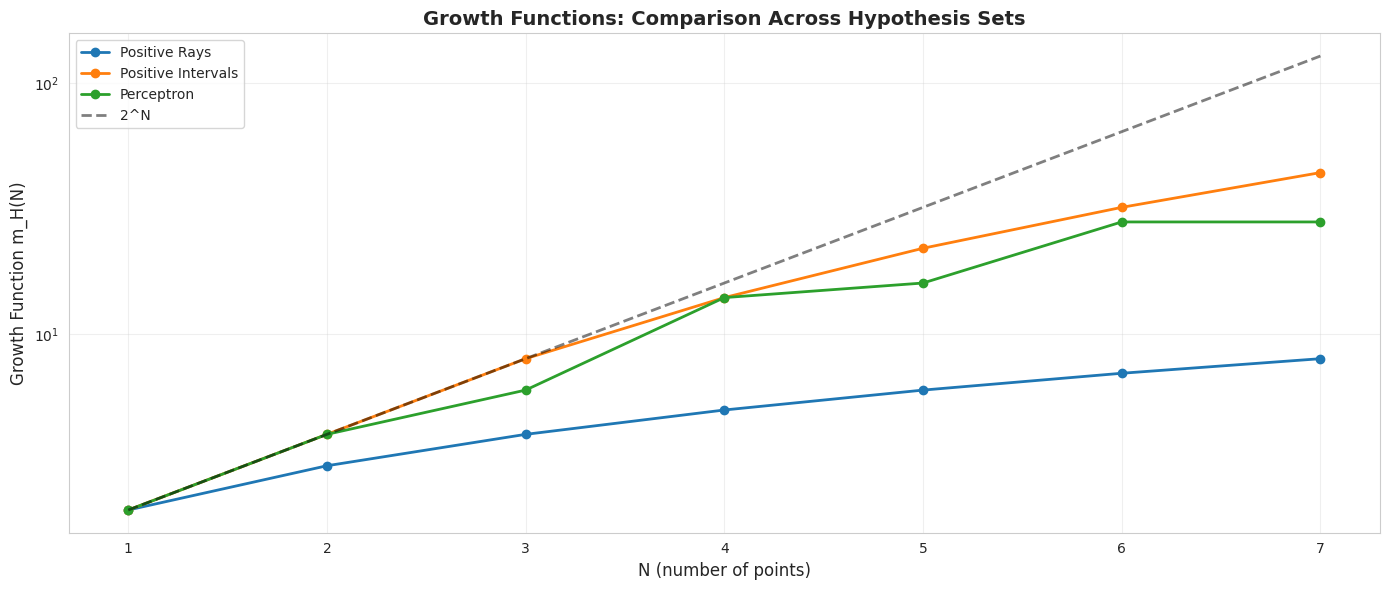

In [23]:
# Create visualizer.
visualizer = mtugrowf.GrowthFunctionVisualizer(figsize=(14, 6))

# Compute growth curves for all hypothesis sets.
generator = mtugrowf.PointGenerator(seed=42)
n_range = list(range(1, 8))

results = {}
for name, tester_class in [
    ("Positive Rays", mtugrowf.PositiveRaysTester),
    ("Positive Intervals", mtugrowf.PositiveIntervalsTester),
    ("Perceptron", lambda: mtugrowf.PerceptronTester(random_state=42)),
]:
    tester = tester_class()
    calculator = mtugrowf.GrowthFunctionCalculator(
        tester, verbose=False, show_progress=False
    )
    results[name] = calculator.compute_growth_curve(
        generator, n_range=n_range, num_trials=1
    )

# Plot comparison.
visualizer.plot_multiple_growth_curves(
    results, title="Growth Functions: Comparison Across Hypothesis Sets"
)

### Observation

- **Positive Rays**: Linear growth $O(N)$ - very limited expressiveness
- **Positive Intervals**: Quadratic growth $O(N^2)$ - moderate expressiveness
- **Perceptron**: Polynomial growth $O(N^2)$ after break point - good balance
- **Red dashed line**: Exponential $2^N$ - shows what unlimited growth looks like

The key insight: Polynomial growth $\Rightarrow$ learning is feasible!

## Cell 8: Computing Realizable Dichotomies

Let's examine which specific dichotomies are realizable for a small example.

In [24]:
# Create 3 points and test all 8 dichotomies with perceptron.
generator = mtugrowf.PointGenerator(seed=42)
tester = mtugrowf.PerceptronTester(random_state=42)

points = generator.generate_random(n=3, d=2)
enumerator = mtugrowf.DichotomyEnumerator(n=3)

print("=== Testing All Dichotomies for 3 Random 2D Points ===")
print(f"Points:\n{points}\n")
print("Dichotomy | Labels      | Realizable")
print("-" * 45)

realizable_count = 0
for i in range(enumerator.count_dichotomies()):
    labels = enumerator.get_dichotomy(i)
    is_realizable = tester.test_dichotomy(points, labels)
    realizable_count += is_realizable
    labels_str = str(labels).replace(" ", "")
    status = "Yes" if is_realizable else "No"
    print(f"{i:9d} | {labels_str:11s} | {status}")

print(
    f"\nTotal realizable: {realizable_count} / {enumerator.count_dichotomies()}"
)
print(f"Points shattered: {realizable_count == enumerator.count_dichotomies()}")

=== Testing All Dichotomies for 3 Random 2D Points ===
Points:
[[-0.25091976  0.90142861]
 [ 0.46398788  0.19731697]
 [-0.68796272 -0.68801096]]

Dichotomy | Labels      | Realizable
---------------------------------------------
        0 | [-1-1-1]    | Yes
        1 | [1-1-1]     | Yes
        2 | [-11-1]     | Yes
        3 | [11-1]      | Yes
        4 | [-1-11]     | Yes
        5 | [1-11]      | Yes
        6 | [-111]      | Yes
        7 | [111]       | Yes

Total realizable: 8 / 8
Points shattered: True


### Observation

- For 3 random 2D points, all 8 dichotomies are typically realizable
- The perceptron can shatter 3 points in general position
- This demonstrates why VC dimension = 3 for 2D perceptron

## Cell 9: Finding Hypotheses that Realize Dichotomies

We can find the actual hypothesis (e.g., threshold, weights) that realizes a given labeling.

In [25]:
# Find threshold for a positive ray pattern.
tester = mtugrowf.PositiveRaysTester()
generator = mtugrowf.PointGenerator(seed=42)

points = generator.generate_line_1d(n=5)
labels = np.array([-1, -1, 1, 1, 1])

print("=== Finding Hypothesis for Positive Rays ===")
print(f"Points: {points.flatten()}")
print(f"Labels: {labels}")

hypothesis = tester.find_hypothesis(points, labels)
if hypothesis:
    print(f"\nFound threshold: a = {hypothesis['threshold']:.3f}")
    print(f"Rule: h(x) = +1 if x >= {hypothesis['threshold']:.3f}, else -1")

# Find perceptron weights for a linearly separable pattern.
tester_p = mtugrowf.PerceptronTester(random_state=42)
points_2d = np.array([[0, 0], [1, 0], [0, 1], [1, 1]])
labels_2d = np.array([-1, -1, 1, 1])

print("\n=== Finding Hypothesis for Perceptron ===")
print(f"Points:\n{points_2d}")
print(f"Labels: {labels_2d}")

hypothesis_p = tester_p.find_hypothesis(points_2d, labels_2d)
if hypothesis_p:
    w = hypothesis_p["weights"]
    b = hypothesis_p["intercept"]
    print(f"\nFound weights: w = {w}")
    print(f"Found intercept: b = {b:.3f}")
    print(f"Rule: h(x) = sign({w[0]:.3f}*x1 + {w[1]:.3f}*x2 + {b:.3f})")

=== Finding Hypothesis for Positive Rays ===
Points: [-1.  -0.5  0.   0.5  1. ]
Labels: [-1 -1  1  1  1]

Found threshold: a = -0.250
Rule: h(x) = +1 if x >= -0.250, else -1

=== Finding Hypothesis for Perceptron ===
Points:
[[0 0]
 [1 0]
 [0 1]
 [1 1]]
Labels: [-1 -1  1  1]

Found weights: w = [-1.  3.]
Found intercept: b = -1.000
Rule: h(x) = sign(-1.000*x1 + 3.000*x2 + -1.000)


### Observation

- We can find the actual parameters (threshold, weights) that realize a labeling
- This is useful for understanding which hypotheses are "closest" to the data
- For perceptron, sklearn finds a linear separator via the perceptron algorithm

## Cell 10: Edge Cases

Let's test some edge cases to ensure robustness.

In [26]:
# Test with N=1 point.
print("=== Edge Case: N=1 ===")
generator = mtugrowf.PointGenerator(seed=42)

for name, tester in [
    ("Positive Rays", mtugrowf.PositiveRaysTester()),
    ("Perceptron", mtugrowf.PerceptronTester(random_state=42)),
]:
    calculator = mtugrowf.GrowthFunctionCalculator(
        tester, verbose=False, show_progress=False
    )
    if "Rays" in name:
        points = generator.generate_line_1d(n=1)
    else:
        points = generator.generate_random(n=1, d=2)
    result = calculator.compute_growth_function(points)
    print(f"{name:20s}: m_H(1) = {result['m_h_n']}")

# Test with collinear points (edge case for perceptron).
print("\n=== Edge Case: Collinear Points ===")
tester = mtugrowf.PerceptronTester(random_state=42)
calculator = mtugrowf.GrowthFunctionCalculator(
    tester, verbose=False, show_progress=False
)

points_collinear = generator.generate_collinear(n=3, d=2)
result = calculator.compute_growth_function(points_collinear)
print(f"3 collinear points: m_H(3) = {result['m_h_n']}")
print("Expected for general position: 8")
print(f"Collinear breaks shattering: {result['m_h_n'] < 8}")

=== Edge Case: N=1 ===
Positive Rays       : m_H(1) = 2
Perceptron          : m_H(1) = 2

=== Edge Case: Collinear Points ===
3 collinear points: m_H(3) = 6
Expected for general position: 8
Collinear breaks shattering: True


### Observation

- For $N=1$, all hypothesis sets have $m_H(1) = 2$ (trivial)
- Collinear points break the shattering property for perceptrons
- Special configurations can reduce the growth function